<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); 
            padding: 40px 50px; border-radius: 12px; margin-bottom: 20px; color: white; font-family: 'Segoe UI', sans-serif;">

  <h1 style="margin: 0 0 8px 0; font-size: 2.4em; font-weight: 700; letter-spacing: -0.5px;">
    Beam Profile &amp; Gouy Phase
  </h1>

  <p style="margin: 0 0 4px 0; font-size: 1.1em; opacity: 0.85; font-weight: 300; letter-spacing: 1px; text-transform: uppercase;">
    LLO HAM6 · WFS45 Sled · 1064 nm
  </p>

  <hr style="border: none; border-top: 1px solid rgba(255,255,255,0.2); margin: 16px 0;">

  <div style="display: flex; justify-content: space-between; align-items: flex-end;">
    <div>
      <p style="margin: 0; font-size: 1.0em; opacity: 0.9;"><strong>Authors:</strong> Katie Gray &amp; Maryrose Barrios</p>
    </div>
    <div style="text-align: right;">
      <p style="margin: 0; font-size: 1.1em; opacity: 0.75; font-weight: 300;">April 13, 2026</p>
    </div>
  </div>

</div>

In [9]:
import finesse
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── MODEL (design distances) ──
kat1 = finesse.Model()
kat1.parse("""
m input 0 1 0
s s_input_L2 input.p2 L2.p1 L=0.001
lens L2 0.278
s s_L2_R2 L2.p2 R2.p1 L=0.0845
bs R2 1 0 0 45.16
s s_R2_L3 R2.p2 L3.p1 L=0.079
lens L3 -1.111
s s_L3_R3 L3.p2 R3.p1 L=0.083
bs R3 0.5 0.5 0 44.84
s s_R3_WFS1 R3.p3 WFS1_det.p1 L=0.07987
m WFS1_det 0 1 0
""")

lam = 1064e-9
w   = 1.3239e-3 / 2
Rc  = -1470.0045e-3
q_in = finesse.BeamParam(w=w, Rc=Rc, wavelength=lam)

WFS1_design = kat1.propagate_beam('input.p1.i', 'WFS1_det.p2.o', q_in=q_in)

# ── AS-BUILT (measured distances) ──
kat2 = finesse.Model()
kat2.parse("""
m input 0 1 0
s s_input_L2 input.p2 L2.p1 L=0.001
lens L2 0.278
s s_L2_R2 L2.p2 R2.p1 L=0.0838
bs R2 1 0 0 45.16
s s_R2_L3 R2.p2 L3.p1 L=0.0892
lens L3 -1.111
s s_L3_R3 L3.p2 R3.p1 L=0.091
bs R3 0.5 0.5 0 44.84
s s_R3_WFS1 R3.p3 WFS1_det.p1 L=0.171
m WFS1_det 0 1 0
""")

WFS1_built = kat2.propagate_beam('input.p1.i', 'WFS1_det.p2.o', q_in=q_in)


Design WFS1 position          : 327.4 mm
Model   beam radius @ WFS1    : 0.2939 mm
As-built beam radius @ WFS1   : 0.2981 mm  (Δ=+0.0043 mm)
Model   Gouy @ WFS1           : 142.43°
As-built Gouy @ WFS1          : 142.93°  (Δ=+0.51°)


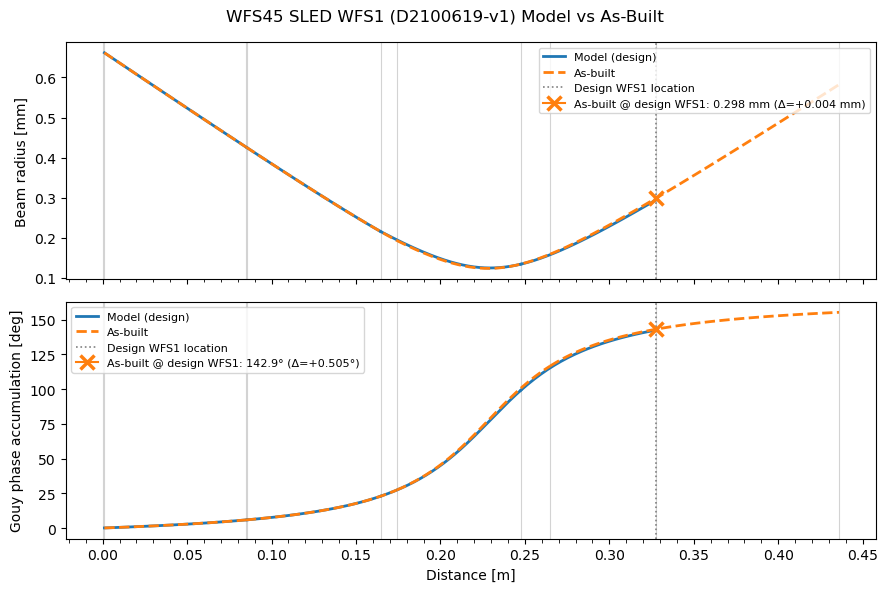

In [10]:
''' WFS-1 Comparison '''

import matplotlib.ticker as ticker
import numpy as np

# ── extract finesse's own smooth line data via throwaway figures ──
fig_m,  axs_m  = WFS1_design.plot()
fig_ab, axs_ab = WFS1_built.plot()

def get_main_lines(ax):
    """Data lines only — filter out finesse's 2-point element boundary vlines."""
    return [l for l in ax.get_lines() if len(l.get_xdata()) > 2]

def get_element_markers(ax):
    """Finesse's 2-point element boundary vlines only."""
    return [l for l in ax.get_lines() if len(l.get_xdata()) == 2]

m_w_lines  = get_main_lines(axs_m[0])
m_g_lines  = get_main_lines(axs_m[1])
ab_w_lines = get_main_lines(axs_ab[0])
ab_g_lines = get_main_lines(axs_ab[1])

# grab element markers BEFORE closing the throwaway figures
m_markers_w  = get_element_markers(axs_m[0])
m_markers_g  = get_element_markers(axs_m[1])
ab_markers_w = get_element_markers(axs_ab[0])
ab_markers_g = get_element_markers(axs_ab[1])

plt.close(fig_m)
plt.close(fig_ab)

# ── as-built value at design PD1 distance ──
z_pd1_model = list(WFS1_design.node_info.values())[-1]['z']
z_end_ab    = list(WFS1_built.node_info.values())[-1]['z']
q_end_ab    = list(WFS1_built.node_info.values())[-1]['q']
dz          = z_pd1_model - z_end_ab

q_at_pd1 = finesse.BeamParam(q=q_end_ab.q + dz, wavelength=lam)
w_at_pd1 = q_at_pd1.w * 1e3   # mm

# Gouy at design WFS1: read from as-built plotted data
ab_g_xdata = np.concatenate([l.get_xdata() for l in ab_g_lines])
ab_g_ydata = np.concatenate([l.get_ydata() for l in ab_g_lines])
sort_idx   = np.argsort(ab_g_xdata)
ab_g_xdata = ab_g_xdata[sort_idx]
ab_g_ydata = ab_g_ydata[sort_idx]
gouy_at_pd1 = ab_g_ydata[np.argmin(np.abs(ab_g_xdata - z_pd1_model))]

# model values at WFS1 for delta calculation
m_g_xdata = np.concatenate([l.get_xdata() for l in m_g_lines])
m_g_ydata = np.concatenate([l.get_ydata() for l in m_g_lines])
m_w_xdata = np.concatenate([l.get_xdata() for l in m_w_lines])
m_w_ydata = np.concatenate([l.get_ydata() for l in m_w_lines])
m_gouy_at_pd1 = m_g_ydata[np.argmin(np.abs(m_g_xdata - z_pd1_model))]
m_w_at_pd1    = m_w_ydata[np.argmin(np.abs(m_w_xdata - z_pd1_model))]

delta_w    = w_at_pd1 - m_w_at_pd1
delta_gouy = gouy_at_pd1 - m_gouy_at_pd1

print(f"Design WFS1 position          : {z_pd1_model*1e3:.1f} mm")
print(f"Model   beam radius @ WFS1    : {m_w_at_pd1:.4f} mm")
print(f"As-built beam radius @ WFS1   : {w_at_pd1:.4f} mm  (Δ={delta_w:+.4f} mm)")
print(f"Model   Gouy @ WFS1           : {m_gouy_at_pd1:.2f}°")
print(f"As-built Gouy @ WFS1          : {gouy_at_pd1:.2f}°  (Δ={delta_gouy:+.2f}°)")

# ── build clean overlay plot ──
fig, (ax_w, ax_g) = plt.subplots(2, 1, sharex=True, figsize=(9, 6))

# --- element boundary markers (drawn first so they sit behind data) ---
seen_w = set()
for line in m_markers_w + ab_markers_w:
    x = line.get_xdata()[0]
    if x not in seen_w:                          # avoid double-drawing same position
        ax_w.axvline(x, color='lightgray', ls='-', lw=0.8, zorder=0)
        seen_w.add(x)

seen_g = set()
for line in m_markers_g + ab_markers_g:
    x = line.get_xdata()[0]
    if x not in seen_g:
        ax_g.axvline(x, color='lightgray', ls='-', lw=0.8, zorder=0)
        seen_g.add(x)

# --- beam size panel ---
for i, line in enumerate(m_w_lines):
    ax_w.plot(line.get_xdata(), line.get_ydata(),
              color='C0', lw=2,
              label='Model (design)' if i == 0 else '_nolegend_')
for i, line in enumerate(ab_w_lines):
    ax_w.plot(line.get_xdata(), line.get_ydata(),
              color='C1', lw=2, ls='--',
              label='As-built' if i == 0 else '_nolegend_')

ax_w.axvline(z_pd1_model, color='gray', ls=':', lw=1.2,
             label='Design WFS1 location')
ax_w.plot(z_pd1_model, w_at_pd1, marker='x', color='C1', ms=10, mew=2.5,
          label=f'As-built @ design WFS1: {w_at_pd1:.3f} mm (Δ={delta_w:+.3f} mm)')
ax_w.set_ylabel('Beam radius [mm]')
ax_w.legend(fontsize=8, loc='upper right')

# --- Gouy panel ---
for i, line in enumerate(m_g_lines):
    ax_g.plot(line.get_xdata(), line.get_ydata(),
              color='C0', lw=2,
              label='Model (design)' if i == 0 else '_nolegend_')
for i, line in enumerate(ab_g_lines):
    ax_g.plot(line.get_xdata(), line.get_ydata(),
              color='C1', lw=2, ls='--',
              label='As-built' if i == 0 else '_nolegend_')

ax_g.axvline(z_pd1_model, color='gray', ls=':', lw=1.2,
             label='Design WFS1 location')
ax_g.plot(z_pd1_model, gouy_at_pd1, marker='x', color='C1', ms=10, mew=2.5,
          label=f'As-built @ design WFS1: {gouy_at_pd1:.1f}° (Δ={delta_gouy:+.3f}°)')
ax_g.set_ylabel('Gouy phase accumulation [deg]')
ax_g.set_xlabel('Distance [m]')
ax_g.legend(fontsize=8, loc='upper left')

# --- axis ticks ---
ax_g.xaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax_g.xaxis.set_minor_locator(ticker.MultipleLocator(0.01))
ax_g.tick_params(which='minor', length=3)

fig.suptitle('WFS45 SLED WFS1 (D2100619-v1) Model vs As-Built')
plt.tight_layout()
plt.show()

In [11]:
# ── MODEL (design distances) ──
kat1 = finesse.Model()
kat1.parse("""
m input 0 1 0
s s_input_L2 input.p2 L2.p1 L=0.001
lens L2 0.278
s s_L2_R2 L2.p2 R2.p1 L=0.0845
bs R2 1 0 0 45.16
s s_R2_L3 R2.p2 L3.p1 L=0.079
lens L3 -1.111
s s_L3_R3 L3.p2 R3.p1 L=0.083
bs R3 0.5 0.5 0 44.84
s s_R3_R4 R3.p2 R4.p1 L=0.384
bs R4 1 0 0 45.04
s s_R4_WFS2 R4.p2 WFS2_det.p1 L=0.05589
m WFS2_det 0 1 0
""")

WFS2_design = kat1.propagate_beam('input.p1.i', 'WFS2_det.p2.o', q_in=q_in)

# ── AS-BUILT (measured distances) ──
kat2 = finesse.Model()
kat2.parse("""
m input 0 1 0
s s_input_L2 input.p2 L2.p1 L=0.001
lens L2 0.278
s s_L2_R2 L2.p2 R2.p1 L=0.0845
bs R2 1 0 0 45.16
s s_R2_L3 R2.p2 L3.p1 L=0.079
lens L3 -1.111
s s_L3_R3 L3.p2 R3.p1 L=0.083
bs R3 0.5 0.5 0 44.84
s s_R3_R4 R3.p2 R4.p1 L=0.424
bs R4 1 0 0 45.04
s s_R4_WFS2 R4.p2 WFS2_det.p1 L=0.171
m WFS2_det 0 1 0
""")

WFS2_built = kat2.propagate_beam('input.p1.i', 'WFS2_det.p2.o', q_in=q_in)

Design WFS2 position          : 687.4 mm
Model   beam radius @ WFS2    : 1.2497 mm
As-built beam radius @ WFS2   : 1.2497 mm  (Δ=-0.0000 mm)
Model   Gouy @ WFS2           : 161.82°
As-built Gouy @ WFS2          : 161.82°  (Δ=-0.00°)


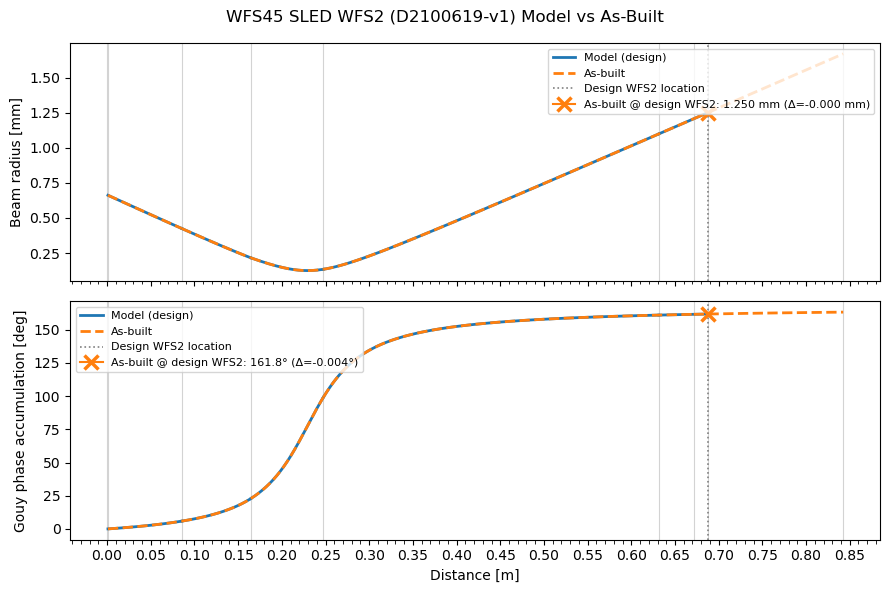

In [12]:
''' WFS-2 Comparison '''

# ── extract finesse's own smooth line data via throwaway figures ──
fig_m,  axs_m  = WFS2_design.plot()
fig_ab, axs_ab = WFS2_built.plot()

def get_main_lines(ax):
    """Data lines only — filter out finesse's 2-point element boundary vlines."""
    return [l for l in ax.get_lines() if len(l.get_xdata()) > 2]

def get_element_markers(ax):
    """Finesse's 2-point element boundary vlines only."""
    return [l for l in ax.get_lines() if len(l.get_xdata()) == 2]

m_w_lines  = get_main_lines(axs_m[0])
m_g_lines  = get_main_lines(axs_m[1])
ab_w_lines = get_main_lines(axs_ab[0])
ab_g_lines = get_main_lines(axs_ab[1])

# grab element markers BEFORE closing the throwaway figures
m_markers_w  = get_element_markers(axs_m[0])
m_markers_g  = get_element_markers(axs_m[1])
ab_markers_w = get_element_markers(axs_ab[0])
ab_markers_g = get_element_markers(axs_ab[1])

plt.close(fig_m)
plt.close(fig_ab)

# ── as-built value at design PD1 distance ──
z_pd1_model = list(WFS2_design.node_info.values())[-1]['z']
z_end_ab    = list(WFS2_built.node_info.values())[-1]['z']
q_end_ab    = list(WFS2_built.node_info.values())[-1]['q']
dz          = z_pd1_model - z_end_ab

q_at_pd1 = finesse.BeamParam(q=q_end_ab.q + dz, wavelength=lam)
w_at_pd1 = q_at_pd1.w * 1e3   # mm

# Gouy at design WFS2: read from as-built plotted data
ab_g_xdata = np.concatenate([l.get_xdata() for l in ab_g_lines])
ab_g_ydata = np.concatenate([l.get_ydata() for l in ab_g_lines])
sort_idx   = np.argsort(ab_g_xdata)
ab_g_xdata = ab_g_xdata[sort_idx]
ab_g_ydata = ab_g_ydata[sort_idx]
gouy_at_pd1 = ab_g_ydata[np.argmin(np.abs(ab_g_xdata - z_pd1_model))]

# model values at WFS2 for delta calculation
m_g_xdata = np.concatenate([l.get_xdata() for l in m_g_lines])
m_g_ydata = np.concatenate([l.get_ydata() for l in m_g_lines])
m_w_xdata = np.concatenate([l.get_xdata() for l in m_w_lines])
m_w_ydata = np.concatenate([l.get_ydata() for l in m_w_lines])
m_gouy_at_pd1 = m_g_ydata[np.argmin(np.abs(m_g_xdata - z_pd1_model))]
m_w_at_pd1    = m_w_ydata[np.argmin(np.abs(m_w_xdata - z_pd1_model))]

delta_w    = w_at_pd1 - m_w_at_pd1
delta_gouy = gouy_at_pd1 - m_gouy_at_pd1

print(f"Design WFS2 position          : {z_pd1_model*1e3:.1f} mm")
print(f"Model   beam radius @ WFS2    : {m_w_at_pd1:.4f} mm")
print(f"As-built beam radius @ WFS2   : {w_at_pd1:.4f} mm  (Δ={delta_w:+.4f} mm)")
print(f"Model   Gouy @ WFS2           : {m_gouy_at_pd1:.2f}°")
print(f"As-built Gouy @ WFS2          : {gouy_at_pd1:.2f}°  (Δ={delta_gouy:+.2f}°)")

# ── build clean overlay plot ──
fig, (ax_w, ax_g) = plt.subplots(2, 1, sharex=True, figsize=(9, 6))

# --- element boundary markers (drawn first so they sit behind data) ---
seen_w = set()
for line in m_markers_w + ab_markers_w:
    x = line.get_xdata()[0]
    if x not in seen_w:                          # avoid double-drawing same position
        ax_w.axvline(x, color='lightgray', ls='-', lw=0.8, zorder=0)
        seen_w.add(x)

seen_g = set()
for line in m_markers_g + ab_markers_g:
    x = line.get_xdata()[0]
    if x not in seen_g:
        ax_g.axvline(x, color='lightgray', ls='-', lw=0.8, zorder=0)
        seen_g.add(x)

# --- beam size panel ---
for i, line in enumerate(m_w_lines):
    ax_w.plot(line.get_xdata(), line.get_ydata(),
              color='C0', lw=2,
              label='Model (design)' if i == 0 else '_nolegend_')
for i, line in enumerate(ab_w_lines):
    ax_w.plot(line.get_xdata(), line.get_ydata(),
              color='C1', lw=2, ls='--',
              label='As-built' if i == 0 else '_nolegend_')

ax_w.axvline(z_pd1_model, color='gray', ls=':', lw=1.2,
             label='Design WFS2 location')
ax_w.plot(z_pd1_model, w_at_pd1, marker='x', color='C1', ms=10, mew=2.5,
          label=f'As-built @ design WFS2: {w_at_pd1:.3f} mm (Δ={delta_w:+.3f} mm)')
ax_w.set_ylabel('Beam radius [mm]')
ax_w.legend(fontsize=8, loc='upper right')

# --- Gouy panel ---
for i, line in enumerate(m_g_lines):
    ax_g.plot(line.get_xdata(), line.get_ydata(),
              color='C0', lw=2,
              label='Model (design)' if i == 0 else '_nolegend_')
for i, line in enumerate(ab_g_lines):
    ax_g.plot(line.get_xdata(), line.get_ydata(),
              color='C1', lw=2, ls='--',
              label='As-built' if i == 0 else '_nolegend_')

ax_g.axvline(z_pd1_model, color='gray', ls=':', lw=1.2,
             label='Design WFS2 location')
ax_g.plot(z_pd1_model, gouy_at_pd1, marker='x', color='C1', ms=10, mew=2.5,
          label=f'As-built @ design WFS2: {gouy_at_pd1:.1f}° (Δ={delta_gouy:+.3f}°)')
ax_g.set_ylabel('Gouy phase accumulation [deg]')
ax_g.set_xlabel('Distance [m]')
ax_g.legend(fontsize=8, loc='upper left')

# --- axis ticks ---
ax_g.xaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax_g.xaxis.set_minor_locator(ticker.MultipleLocator(0.01))
ax_g.tick_params(which='minor', length=3)

fig.suptitle('WFS45 SLED WFS2 (D2100619-v1) Model vs As-Built')
plt.tight_layout()
plt.show()